# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

--

#### a) Potential dataset

Name: **PRH open data service**

Link: https://avoindata.prh.fi/en/krek/swagger-ui

#### b) Brief description of the dataset

The PRH API has a lot of different data, but the specific data I am interested in, is the number of reported cases of lost capital in finnish companies over different years. I might also expand the scope of the project to check different types of companies depending on the data I'm able to collect. 

I am not yet sure how many rows there are, as the API is rate limited and I have yet to create a loop to collect all the necessary data.

#### c) Exploratory data analysis on a sample of the data

*I am doing two requests with manual dates selected for my sample data and append the results as I have yet to create a loop for the request. This approach is very clumsy but just a temporary fix to be able to conduct exploratory data analysis.

In [1]:
# --- Task 0: Course project dataset exploration ---

import requests
import pandas as pd

url_ytj = "https://avoindata.prh.fi/opendata-registerednotices-api/v3/"
params_1 = {
    "entryCode": "OPOMEN", # Register entry: lost capital
    "noticeRegistrationDateStart": "2025-01-01",
    "noticeRegistrationDateEnd": "2025-01-31"
}
response_ytj_1 = requests.get(url_ytj, params=params_1)

response_ytj_1

params_2 = {
    "entryCode": "OPOMEN", # Register entry: lost capital
    "noticeRegistrationDateStart": "2025-02-01",
    "noticeRegistrationDateEnd": "2025-02-28"
}
response_ytj_2 = requests.get(url_ytj, params=params_2)

response_ytj_2

<Response [200]>

In [2]:
ytj_data_1 = response_ytj_1.json()
ytj_data_2 = response_ytj_2.json()

# Returns the first report matching "OPOMEN" (Lost Capital) as the API returns all reports of a company that contains "OPOMEN" 
for company in ytj_data_1["companies"]:
    for notice in company["publicNotices"]:
        if "OPOMEN" in notice["entryCodes"]:
            company["publicNotices"] = notice

for company in ytj_data_2["companies"]:
    for notice in company["publicNotices"]:
        if "OPOMEN" in notice["entryCodes"]:
            company["publicNotices"] = notice

df_lost_capital_1 = pd.json_normalize(
    ytj_data_1["companies"],
    record_path="names",
    meta=[["publicNotices", "registrationDate"], ["publicNotices", "entryCodes"]],
    errors="ignore"
    )

df_lost_capital_2 = pd.json_normalize(
    ytj_data_2["companies"],
    record_path="names",
    meta=[["publicNotices", "registrationDate"], ["publicNotices", "entryCodes"]],
    errors="ignore"
    )

# Appends the two samples
df_lost_capital = pd.concat([df_lost_capital_1, df_lost_capital_2])

# Changes date column to DateTime format and changes columns to month names
df_lost_capital["publicNotices.registrationDate"] = pd.to_datetime(df_lost_capital["publicNotices.registrationDate"])
df_lost_capital["registrationMonth"] = df_lost_capital["publicNotices.registrationDate"].dt.month_name()

df_lost_capital.head(5)

,name,type,registrationDate,version,source,endDate,publicNotices.registrationDate,publicNotices.entryCodes,registrationMonth
0,Hansa Ecuras Oy,1,2000-06-14,1,1,NaN,2025-01-08,[OPOMEN],January
1,Kangasalan Kirjanpitotoimisto Oy,1,1986-11-05,2,1,2000-06-13,2025-01-08,[OPOMEN],January
2,Natur Pine Oy,1,1997-05-20,1,1,NaN,2025-01-14,[OPOMEN],January
3,Ullastiina Ompelimo ja Pesulapalvelut,3,2025-01-15,1,1,NaN,2025-01-14,[OPOMEN],January
4,Ullastiina Asustehuolto,3,1999-11-04,1,1,NaN,2025-01-14,[OPOMEN],January


In [3]:
df_lost_capital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 189 entries, 0 to 87
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            189 non-null    object        
 1   type                            189 non-null    object        
 2   registrationDate                189 non-null    object        
 3   version                         189 non-null    int64         
 4   source                          189 non-null    object        
 5   endDate                         40 non-null     object        
 6   publicNotices.registrationDate  189 non-null    datetime64[ns]
 7   publicNotices.entryCodes        189 non-null    object        
 8   registrationMonth               189 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 14.8+ KB


In [4]:
df_lost_capital.describe()

,version,publicNotices.registrationDate
count,189.000000,189
mean,1.132275,2025-01-23 10:47:37.142857216
min,1.000000,2025-01-01 00:00:00
25%,1.000000,2025-01-13 00:00:00
50%,1.000000,2025-01-15 00:00:00
75%,1.000000,2025-02-06 00:00:00
max,2.000000,2025-02-11 00:00:00
std,0.339689,NaN


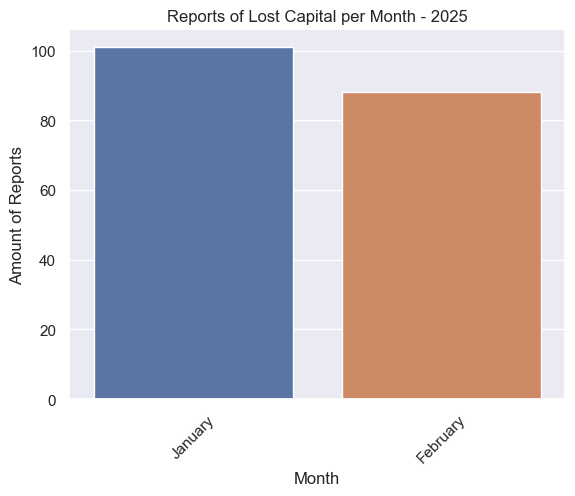

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# Changes date column to DateTime format and changes columns to month names
df_lost_capital["publicNotices.registrationDate"] = pd.to_datetime(df_lost_capital["publicNotices.registrationDate"])
df_lost_capital["registrationMonth"] = df_lost_capital["publicNotices.registrationDate"].dt.month_name()

# Creates a pivot table grouped by months and a count of the number of reports per months
lost_capital_per_month = df_lost_capital.pivot_table(
    index="registrationMonth",
    values="name",
    aggfunc="count"
).rename_axis(columns=None).reset_index()

# Sorts columns in the right order
month_order = ["January", "February"]
lost_capital_per_month["registrationMonth"] = pd.Categorical(lost_capital_per_month["registrationMonth"], categories=month_order, ordered=True)
lost_capital_per_month = lost_capital_per_month.sort_values("registrationMonth")

barplot_per_month = sns.barplot(data=lost_capital_per_month, x="registrationMonth", y="name", hue="registrationMonth")
plt.xticks(rotation=45)
barplot_per_month.set_title("Reports of Lost Capital per Month - 2025")
barplot_per_month.set_xlabel("Month")
barplot_per_month.set_ylabel("Amount of Reports")
plt.show()

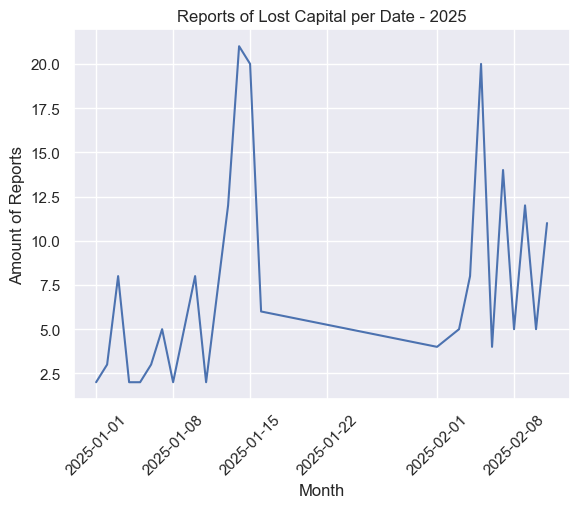

In [6]:
# Creates a pivot table grouped by date and a count of the number of reports per date

lost_capital_per_date = df_lost_capital.pivot_table(
    index="publicNotices.registrationDate",
    values="name",
    aggfunc="count"
).rename_axis(columns=None).reset_index()

lineplot_per_date = sns.lineplot(data=lost_capital_per_date, x="publicNotices.registrationDate", y="name")
plt.xticks(rotation=45)
lineplot_per_date.set_title("Reports of Lost Capital per Date - 2025")
lineplot_per_date.set_xlabel("Month")
lineplot_per_date.set_ylabel("Amount of Reports")
plt.show()

---

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [7]:
# --- Task 1: Setting up an API key and .env file ---

from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

api_key = os.environ.get("MARKETSTACK_API_KEY")

print(f"Key loaded: {api_key[:5]}...")

Key loaded: 68144...


---

### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [8]:
# --- Task 2: Retrieving data from MarketStack ---

import requests

# a) Retrieve End-of-Day (eod) data for FAANG for March 2026

url = "https://api.marketstack.com/v2/eod"
params = {
    "access_key": api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31"
}

response = requests.get(url, params=params)
stocks_data = response.json()

response

<Response [200]>

In [9]:
# b) Convert the retrieved JSON data into a pandas DataFrame and print the first 5 rows

import pandas as pd

df_stocks_data = pd.DataFrame(stocks_data["data"])

df_stocks_data.head(5)

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,1X GOOG,None,ETF,EUR,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,"Meta Platforms, Inc.",None,Stock,ARS,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NETFLIX INC,None,None,MXN,NFLX,XNAS,2026-03-31T00:00:00+0000


In [30]:
# c) Compute summary statistics for the closing prices grouped by stock

# Sorts by chronological order
df_stocks_data = df_stocks_data.sort_values("date")

# Summary statistics for closing per stock
print("Summary statistics per stock:")
display(df_stocks_data.groupby("symbol")["close"].describe())

# Groups the summary by stock and looks for the first and last value of close
df_stock_close = df_stocks_data.groupby("symbol").agg(
    first_close=pd.NamedAgg(column="close", aggfunc="first"),
    last_close=pd.NamedAgg(column="close", aggfunc="last")
).rename_axis(columns=None).reset_index()

# Calculates the return percentage for each stock over the month
df_stock_close["stock_return"] = round((df_stock_close["last_close"] / df_stock_close["first_close"] - 1) * 100, 2)

# Displays the Dataframe with the numbers
print("Dataframe with the numbers:")
display(df_stock_close)

# Finds the index of the best and worst performers
best_stock = df_stock_close["stock_return"].idxmax()
worst_stock = df_stock_close["stock_return"].idxmin()

print(f"Best performer:  {best_stock} {df_stock_close.loc[best_stock]["stock_return"]}")
print(f"Worst performer: {worst_stock} {df_stock_close.loc[worst_stock]["stock_return"]}")

Summary statistics per stock:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,20.0,253.9735,4.843451,246.63,250.0750,252.855,258.0650,262.52
AMZN,20.0,210.1385,4.856686,199.34,207.6375,210.005,213.2800,218.94
GOOG,20.0,297.2825,11.232111,273.14,289.4925,301.185,305.8000,309.41
META,20.0,611.0580,41.315247,525.72,593.4750,614.695,645.4925,667.73
NFLX,20.0,94.8445,2.518470,90.92,93.2325,94.530,96.3475,99.17


Dataframe with the numbers:


,symbol,first_close,last_close,stock_return
0,AAPL,262.52,253.79,-3.33
1,AMZN,216.82,208.27,-3.94
2,GOOG,303.45,286.86,-5.47
3,META,667.73,572.13,-14.32
4,NFLX,98.66,96.15,-2.54


Best performer:  4 -2.54
Worst performer: 3 -14.32


---

### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

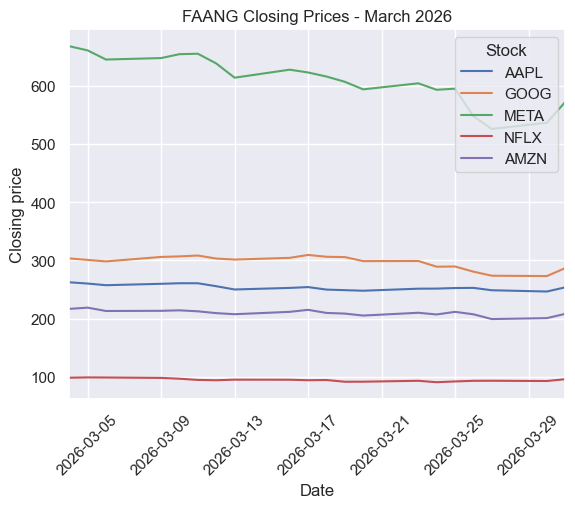

In [11]:
# --- Task 3: Visualizing stock data ---

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# a) A line chart showing the closing price of each stock over time during March 2026

df_stocks_data["date"] = pd.to_datetime(df_stocks_data["date"]).dt.date

stocks_line_chart = sns.lineplot(data=df_stocks_data, x="date", y="close", hue="symbol")

# Customizing labels and titles
stocks_line_chart.set_ylabel("Closing price")
stocks_line_chart.set_xlabel("Date")
stocks_line_chart.set_title("FAANG Closing Prices - March 2026")
stocks_line_chart.legend(title="Stock")
plt.xticks(rotation=45) # rotates the ticks for the x axis 45 degrees to avoid overlap
stocks_line_chart.set_xlim(
    df_stocks_data["date"].min(),
    df_stocks_data["date"].max()
) # removes the dates outside of march

plt.show()

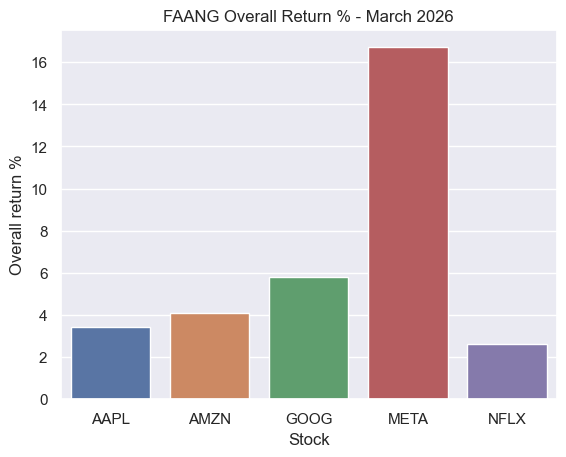

In [12]:
# b) A bar plot showing the overall return percentage for each stock in March 2026

overall_return_bar_plot = sns.barplot(data=df_stock_close, x="symbol", y="stock_return", hue="symbol")

overall_return_bar_plot.set_title("FAANG Overall Return % - March 2026")
overall_return_bar_plot.set_xlabel("Stock")
overall_return_bar_plot.set_ylabel("Overall return %")

plt.show()

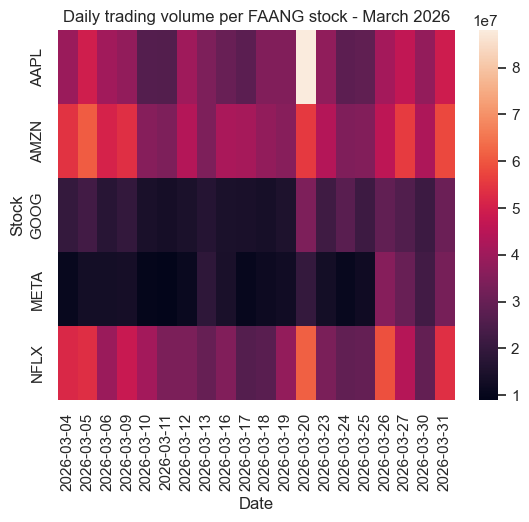

In [13]:
# c) A heatmap showing the daily trading volume for each stock

daily_trading_volume = df_stocks_data.pivot(index="symbol", columns="date", values="volume")

daily_trading_heatmap = sns.heatmap(daily_trading_volume)

# Customizing labels and titles
daily_trading_heatmap.set_title("Daily trading volume per FAANG stock - March 2026")
daily_trading_heatmap.set_xlabel("Date")
daily_trading_heatmap.set_ylabel("Stock")

plt.show()

---

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [14]:
# --- Task 4: Exporting and importing data ---

import json

# a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`

with open("exports/stockdata.json", "w") as f:
    json.dump(stocks_data, f, indent=2)

In [15]:
# b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder

df_stocks_data.to_csv("exports/stockdata.csv", index=False)

In [16]:
# c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2

with open("exports/stockdata.json", "r") as f:
    json_import = json.load(f)

display(json_import["data"][:5])

csv_import = pd.read_csv("exports/stockdata.csv")
csv_import.head(5)

[{'open': 247.89,
  'high': 255.48,
  'low': 247.101,
  'close': 253.79,
  'volume': 48770963.0,
  'adj_high': 255.48,
  'adj_low': 247.101,
  'adj_close': 253.79,
  'adj_open': 247.91,
  'adj_volume': 49598091.0,
  'split_factor': 1.0,
  'dividend': 0.0,
  'name': 'Apple Inc',
  'exchange_code': 'NASDAQ',
  'asset_type': 'Stock',
  'price_currency': 'USD',
  'symbol': 'AAPL',
  'exchange': 'XNAS',
  'date': '2026-03-31T00:00:00+0000'},
 {'open': 204.875,
  'high': 210.28,
  'low': 204.14,
  'close': 208.27,
  'volume': 57843337.0,
  'adj_high': 210.28,
  'adj_low': 204.14,
  'adj_close': 208.27,
  'adj_open': 204.845,
  'adj_volume': 58470078.0,
  'split_factor': 1.0,
  'dividend': 0.0,
  'name': 'Amazon.com Inc',
  'exchange_code': 'NASDAQ',
  'asset_type': 'Stock',
  'price_currency': 'USD',
  'symbol': 'AMZN',
  'exchange': 'XNAS',
  'date': '2026-03-31T00:00:00+0000'},
 {'open': 277.84,
  'high': 287.05,
  'low': 276.81,
  'close': 286.86,
  'volume': 30680107.0,
  'adj_high': 287

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-31
1,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,1X GOOG,NaN,ETF,EUR,GOOG,XNAS,2026-03-31
2,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,"Meta Platforms, Inc.",NaN,Stock,ARS,META,ARCX,2026-03-31
3,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NETFLIX INC,NaN,NaN,MXN,NFLX,XNAS,2026-03-31
4,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-31


---

### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [46]:
# --- Task 5: Querying the Northwind database ---

import sqlite3

# a) Connect to the database and list all tables it contains

connection = sqlite3.connect("database/northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [34]:
# b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it

products_above_30 = pd.read_sql_query("""
    SELECT  ProductName,
            UnitPrice,
            UnitsInStock
    FROM Products
    WHERE Unitprice > 30
    """
, connection)

display(products_above_30)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [35]:
# c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, 
# and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. 
# Load the result into a DataFrame and print it.

orders_data = pd.read_sql_query("""
    SELECT CompanyName,
           o.OrderID,
           OrderDate,
           ShipCountry,
           UnitPrice,
           UnitPrice * Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE ShipCountry = "Germany"
    """
, connection)

orders_data["OrderDate"] = pd.to_datetime(orders_data["OrderDate"], format="mixed") # Changes date column to DateTime format

display(orders_data)

,CompanyName,OrderID,OrderDate,ShipCountry,UnitPrice,LineTotal
0,Toms Spezialitäten,10249,2016-07-05 00:00:00,Germany,18.60,167.4
1,Toms Spezialitäten,10249,2016-07-05 00:00:00,Germany,42.40,1696.0
2,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,7.70,123.2
3,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,15.60,780.0
4,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,39.40,591.0
...,...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,36.00,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,15.00,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,15.00,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,10.00,500.0


---

### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

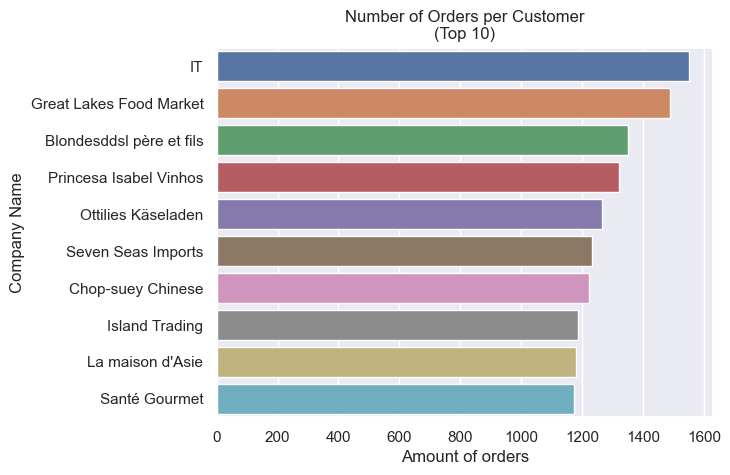

In [36]:
# --- Task 6 : Visualizing Northwind data ---

# a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany)

top_customers = orders_data.pivot_table(index="CompanyName", values="OrderID", aggfunc="count").sort_values("OrderID", ascending=False).head(10)

order_per_customer_barplot = sns.barplot(data=top_customers, x="OrderID", y="CompanyName", hue="CompanyName")

# Customizing labels and titles
order_per_customer_barplot.set_title("Number of Orders per Customer\n(Top 10)")
order_per_customer_barplot.set_ylabel("Company Name")
order_per_customer_barplot.set_xlabel("Amount of orders")

plt.show()

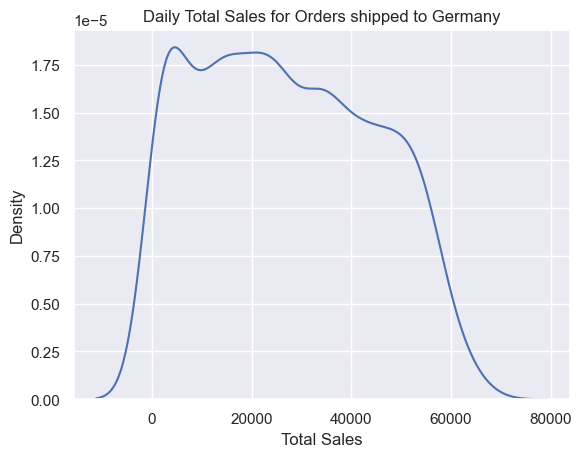

In [37]:
# b) Compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany.
# The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

total_sales_per_date = orders_data.pivot_table(index="OrderDate", values="LineTotal", aggfunc="sum")

sales_per_date_kde = sns.kdeplot(data=total_sales_per_date, x="LineTotal")

# Customizing labels and titles
sales_per_date_kde.set_title("Daily Total Sales for Orders shipped to Germany")
sales_per_date_kde.set_xlabel("Total Sales")
sales_per_date_kde.set_ylabel("Density")

plt.show()

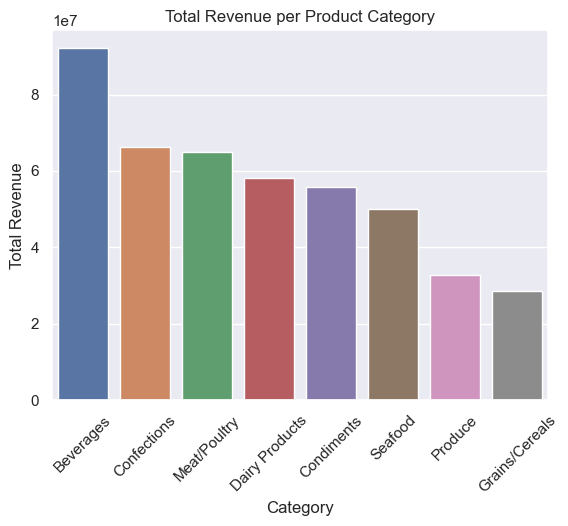

In [38]:
# c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue
# per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

total_revenue_per_category = pd.read_sql_query("""
    SELECT cat.CategoryName,
           SUM(od.Quantity * p.UnitPrice) AS TotalRevenue
    FROM "Order Details" od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    """
, connection).sort_values("TotalRevenue", ascending=False)

revenue_per_category_barplot = sns.barplot(data=total_revenue_per_category, x="CategoryName", y="TotalRevenue", hue="CategoryName")

# Customizing labels and titles
revenue_per_category_barplot.set_title("Total Revenue per Product Category")
revenue_per_category_barplot.set_xlabel("Category")
revenue_per_category_barplot.set_ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [39]:
# --- Task 7 : Comparing Python to SQL ---

# a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. 
# Print the first 5 rows of each

full_products = pd.read_sql_query("SELECT * FROM Products", connection)
full_categories = pd.read_sql_query("SELECT * FROM Categories", connection)

display(full_products.head(5))
display(full_categories.head(5))

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [40]:
# b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`

merged_products_categories = pd.merge(full_products, full_categories, how="inner", on="CategoryID")

merged_products_categories.head(5)

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [41]:
%%time

# c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas.
# Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c)
# versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b).
# Print both execution times and briefly comment on which was faster.


# Approach 1: Let SQL do the work (a lot faster)
join_fully_SQL = pd.read_sql_query("""
    SELECT cat.CategoryName,
           SUM(od.Quantity * p.UnitPrice) AS TotalRevenue
    FROM "Order Details" od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    """
, connection)

CPU times: total: 469 ms
Wall time: 458 ms


In [48]:
%%time

# Approach 2: Pull all tables into Python, then join (worse, usually takes over 2x the time)
full_products = pd.read_sql_query("SELECT * FROM Products", connection)
full_categories = pd.read_sql_query("SELECT * FROM Categories", connection)
full_order_details = pd.read_sql_query("SELECT * FROM 'Order Details'", connection)

merged_products_categories = pd.merge(full_products, full_categories, how="inner", on="CategoryID")
merged_all = pd.merge(merged_products_categories, full_order_details, how="inner", on="ProductID")

merged_all["TotalRevenue"] = merged_all["UnitPrice_x"] * merged_all["Quantity"]
grouped_in_python = merged_all.groupby("CategoryName")["TotalRevenue"].sum().reset_index()

CPU times: total: 1.19 s
Wall time: 1.26 s


In [50]:
# Closing the connection
connection.close()

### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [27]:
# --- Task 8 : Wide and long format ---

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion

converted_to_long = wide_data.melt(
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("Before converting:")
display(wide_data)

print("After converting:")
display(converted_to_long)


Before converting:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After converting:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [28]:
# b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion

converted_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).rename_axis(columns=None).reset_index()

print("Before converting:")
display(long_data)

# Sorts the months in the right order using pd.Categorical
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]
converted_to_wide["month"] = pd.Categorical(converted_to_wide["month"], categories=month_order, ordered=True)
converted_to_wide = converted_to_wide.sort_values("month")

print("After converting:")
display(converted_to_wide)

Before converting:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


After converting:


,month,Laptop,Phone
1,Jan,45,120
0,Feb,50,110
2,Mar,55,130


In [29]:
# c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals

convert_back_to_wide = converted_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).rename_axis(columns=None).reset_index()

print("Original wide:")
display(wide_data)
print("Converted back to wide:")
display(convert_back_to_wide)

convert_back_to_long = converted_to_wide.melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

# Sorts the months in the right order using pd.Categorical
convert_back_to_long["month"] = pd.Categorical(convert_back_to_long["month"], categories=month_order, ordered=True)
convert_back_to_long = convert_back_to_long.sort_values("month", ascending=True)

print("Original long:")
display(long_data)
print("Converted back to long:")
display(convert_back_to_long)

Original wide:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Converted back to wide:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Original long:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


Converted back to long:


,month,product,units_sold
0,Jan,Laptop,45
3,Jan,Phone,120
1,Feb,Laptop,50
4,Feb,Phone,110
2,Mar,Laptop,55
5,Mar,Phone,130


---

### AI usage:

I tried to avoid using AI in general, but used it to explain some concepts. I used ChatGPT in combination with Stack Overflow to fix an issue with overlapping data labels in Task 3 a).